In [16]:
import torchaudio
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Record audio from microphone
def record_audio(duration=3, sample_rate=16000):
    waveform, sample_rate = torchaudio.load("speech.wav")
    if waveform.size(0) > 1:  # If stereo, convert to mono by averaging channels
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform, sample_rate  # shape: (1, T)

# 2. Convert to MFCC
def compute_mfcc(audio, sample_rate, n_mfcc=13):
    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )
    mfcc = mfcc_transform(audio)  # shape: (1, n_mfcc, time)
    return mfcc.squeeze(0).T  # shape: (time, n_mfcc)

# 3. Apply k-means clustering
def cluster_mfcc(mfcc, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels = kmeans.fit_predict(mfcc.numpy())
    return labels, kmeans.cluster_centers_

# 4. Visualize clusters using t-SNE
def visualize_clusters(mfcc, labels):
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(mfcc.numpy())
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=10)
    plt.title("MFCC Clusters (t-SNE Projection)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2") 
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

def mel_spectrogram(waveform, sample_rate, hop_length=160, n_fft=400, n_mels=40):
    # Compute mel spectrogram
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    mel_spec = mel_transform(waveform)  # shape: (1, n_mels, time_frames)
    mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)

    # Convert to numpy for plotting
    mel_spec_np = mel_spec_db.squeeze(0).numpy()

    # Create figure with two subplots
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 10))

    # Plot 1: Original mel spectrogram
    im1 = ax1.imshow(mel_spec_np, aspect='auto', origin='lower', cmap='viridis')
    ax1.set_title('Mel Spectrogram', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Mel Frequency Bin', fontsize=12)
    ax1.set_xlabel('Time Frame', fontsize=12)
    plt.show()

torch.Size([5060, 13])


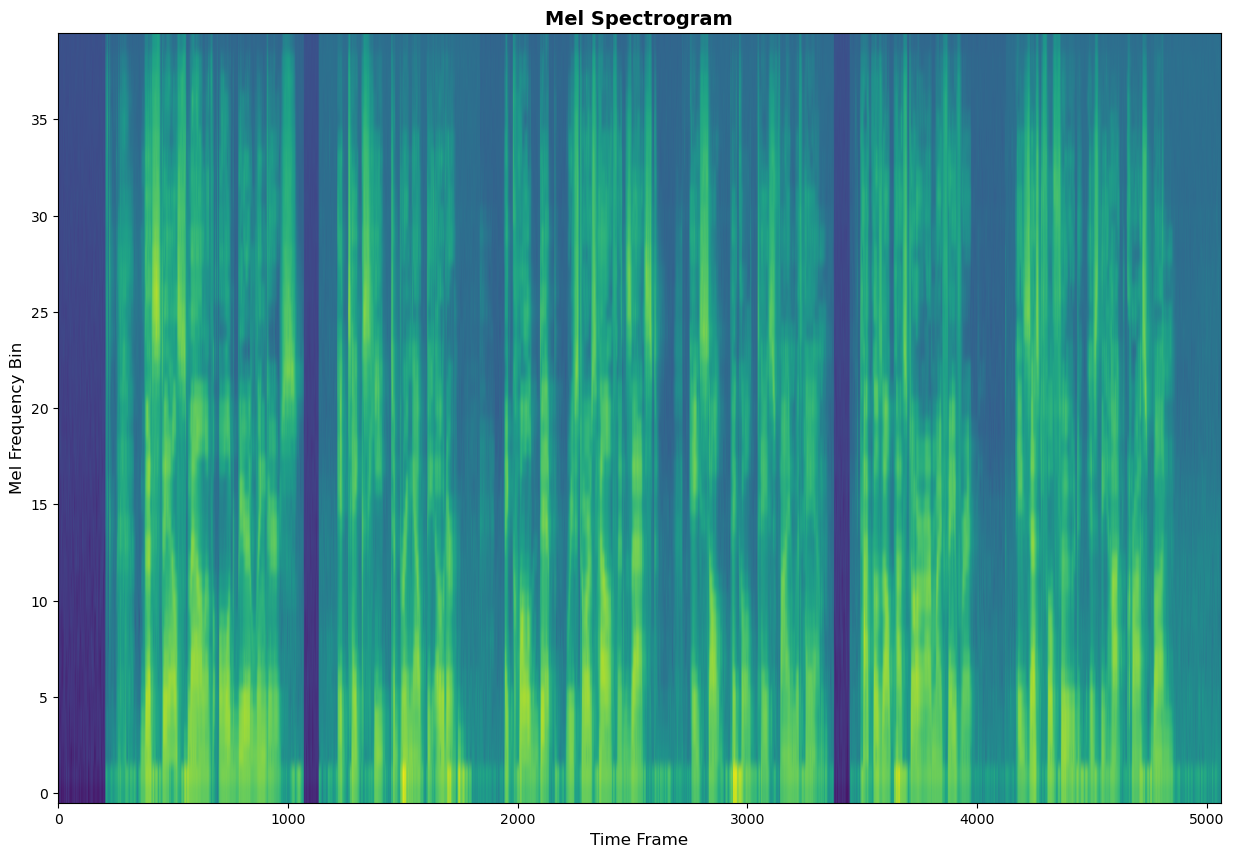

In [17]:
audio, sr = record_audio(duration=3)
mfcc = compute_mfcc(audio, sr)
print(mfcc.shape)
mel_spectrogram(audio, sr)

In [ ]:
labels, centers = cluster_mfcc(mfcc, n_clusters=10)

In [ ]:
visualize_clusters(mfcc, labels)

In [ ]:
import numpy as np
import torchaudio
import random
from IPython.display import Audio

# New: Play selected audio clips for each cluster
def play_cluster_examples(waveform, sample_rate, labels, hop_length, cluster_id, mfcc_window_ms=25, max_examples=10):
    frame_indices = np.where(labels == cluster_id)[0]
    if len(frame_indices) == 0:
        print(f"No examples found for cluster {cluster_id}")
        return
    
    selected = random.sample(list(frame_indices), min(max_examples, len(frame_indices)))
    print(f"\n🎧 Playing {len(selected)} examples from Cluster {cluster_id}:")

    for idx in selected:
        start_sample = idx * hop_length
        frame_length = int((mfcc_window_ms / 1000.0) * sample_rate)  # typically 25ms = 400 samples at 16kHz
        end_sample = start_sample + frame_length
        clip = waveform[0, start_sample:end_sample]
        display(Audio(clip.numpy(), rate=sample_rate))


In [ ]:
waveform, sample_rate = record_audio()
mfcc = compute_mfcc(waveform, sample_rate)
labels, centers = cluster_mfcc(mfcc, n_clusters=10)
visualize_clusters(mfcc, labels)

hop_length = 160  # same as used in MFCC transform

# Play 10 audio examples from each cluster
for cluster_id in range(2):
    play_cluster_examples(waveform, sample_rate, labels, hop_length, cluster_id)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchaudio

def plot_mel_spectrogram_with_clusters(waveform, sample_rate, labels, hop_length=160, n_fft=400, n_mels=40):
    """
    Plot mel spectrogram with cluster regions marked in different colors.
    
    Args:
        waveform: Audio waveform tensor (1, T)
        sample_rate: Audio sample rate
        labels: Cluster labels for each time frame
        hop_length: Hop length used in MFCC computation
        n_fft: FFT window size
        n_mels: Number of mel frequency bins
    """
    
    # Compute mel spectrogram
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    
    mel_spec = mel_transform(waveform)  # shape: (1, n_mels, time_frames)
    mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)
    
    # Convert to numpy for plotting
    mel_spec_np = mel_spec_db.squeeze(0).numpy()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Original mel spectrogram
    im1 = ax1.imshow(mel_spec_np, aspect='auto', origin='lower', cmap='viridis')
    ax1.set_title('Mel Spectrogram', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Mel Frequency Bin', fontsize=12)
    ax1.set_xlabel('Time Frame', fontsize=12)
    
    # Add colorbar for mel spectrogram
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Power (dB)', fontsize=10)
    
    # Plot 2: Mel spectrogram with cluster overlays
    im2 = ax2.imshow(mel_spec_np, aspect='auto', origin='lower', cmap='viridis')
    ax2.set_title('Mel Spectrogram with Cluster Markings', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Mel Frequency Bin', fontsize=12)
    ax2.set_xlabel('Time Frame', fontsize=12)
    
    # Add colorbar for mel spectrogram
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Power (dB)', fontsize=10)
    
    # Create cluster overlay
    n_clusters = len(np.unique(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    # Create a mask for each cluster and overlay it
    for cluster_id in range(n_clusters):
        cluster_mask = (labels == cluster_id)
        
        # Create a colored overlay for this cluster
        overlay = np.zeros((mel_spec_np.shape[0], mel_spec_np.shape[1], 4))
        overlay[:, cluster_mask, :3] = colors[cluster_id][:3]  # RGB
        overlay[:, cluster_mask, 3] = 0.3  # Alpha (transparency)
        
        # Apply the overlay
        ax2.imshow(overlay, aspect='auto', origin='lower', alpha=0.3)
    
    # Add cluster legend
    legend_elements = [patches.Patch(color=colors[i], label=f'Cluster {i}') 
                      for i in range(n_clusters)]
    ax2.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.tight_layout()
    plt.show()
    
    # Print cluster statistics
    print("\n�� Cluster Statistics:")
    for cluster_id in range(n_clusters):
        cluster_size = np.sum(labels == cluster_id)
        cluster_percentage = (cluster_size / len(labels)) * 100
        print(f"Cluster {cluster_id}: {cluster_size} frames ({cluster_percentage:.1f}%)")
        
        
def plot_cluster_boundaries(waveform, sample_rate, labels, hop_length=160, n_fft=400, n_mels=40):
    """
    Plot mel spectrogram with cluster boundaries marked as vertical lines.
    """
    
    # Compute mel spectrogram
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    
    mel_spec = mel_transform(waveform)
    mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)
    mel_spec_np = mel_spec_db.squeeze(0).numpy()
    
    plt.figure(figsize=(15, 8))
    im = plt.imshow(mel_spec_np, aspect='auto', origin='lower', cmap='viridis')
    plt.title('Mel Spectrogram with Cluster Boundaries', fontsize=14, fontweight='bold')
    plt.ylabel('Mel Frequency Bin', fontsize=12)
    plt.xlabel('Time Frame', fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Power (dB)', fontsize=10)
    
    # Find cluster boundaries
    boundaries = []
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            boundaries.append(i)
    
    # Draw vertical lines at boundaries
    n_clusters = len(np.unique(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    for i, boundary in enumerate(boundaries):
        plt.axvline(x=boundary, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    # Add cluster labels in the middle of each cluster region
    current_cluster = labels[0]
    start_frame = 0
    
    for i in range(1, len(labels)):
        if labels[i] != current_cluster:
            # Label the previous cluster
            mid_frame = (start_frame + i - 1) // 2
            plt.text(mid_frame, mel_spec_np.shape[0] // 2, f'C{current_cluster}', 
                    color=colors[current_cluster], fontsize=12, fontweight='bold',
                    ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', 
                    facecolor='white', alpha=0.8))
            current_cluster = labels[i]
            start_frame = i
    
    # Label the last cluster
    mid_frame = (start_frame + len(labels) - 1) // 2
    plt.text(mid_frame, mel_spec_np.shape[0] // 2, f'C{current_cluster}', 
            color=colors[current_cluster], fontsize=12, fontweight='bold',
            ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', 
            facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

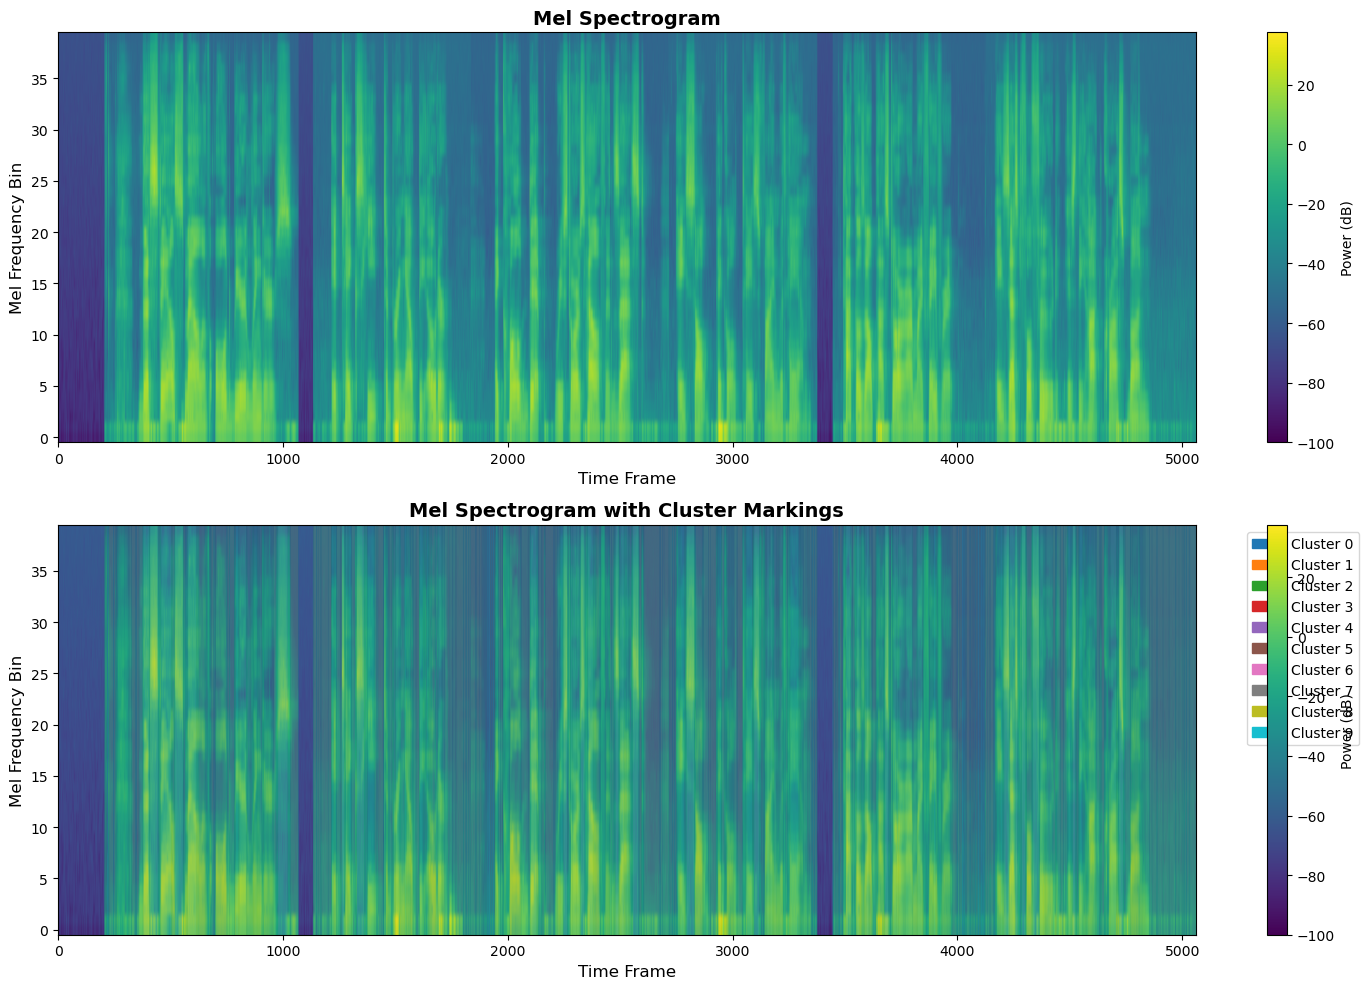


�� Cluster Statistics:
Cluster 0: 417 frames (8.2%)
Cluster 1: 1055 frames (20.8%)
Cluster 2: 452 frames (8.9%)
Cluster 3: 313 frames (6.2%)
Cluster 4: 404 frames (8.0%)
Cluster 5: 438 frames (8.7%)
Cluster 6: 467 frames (9.2%)
Cluster 7: 427 frames (8.4%)
Cluster 8: 552 frames (10.9%)
Cluster 9: 535 frames (10.6%)


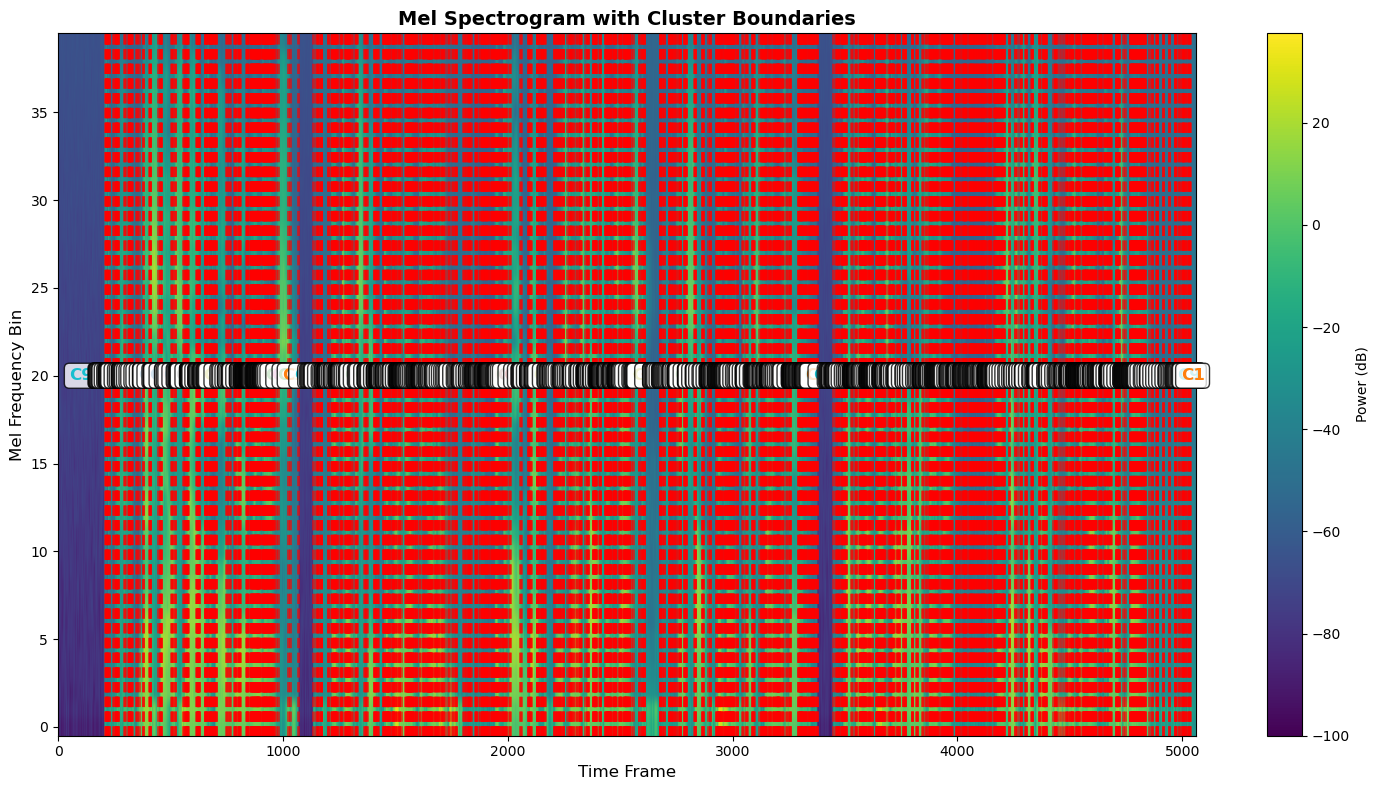

In [9]:
# After you have your waveform, sample_rate, and labels
plot_mel_spectrogram_with_clusters(waveform, sample_rate, labels)
plot_cluster_boundaries(waveform, sample_rate, labels)